In this script I will be illustrating the differences in the performance of the normal evolve() method and the serial and safe serial methods in the Evolver class. The regular method is called by evolve(method = 'regular') and likewise the serial method by evolve(method = 'serial').

I will not be explaining in depth how the pulses, pulse sequences, or the spin system are handled. For these, please see the other two tutorials I've created, Evolver_Rabiexample-Copy1.ipynb and Evolver_Ramseyexample-Copy1.ipynb. 

In [1]:
from qutip import *
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt
import matplotlib
import time
import random

import sys
import os

In [2]:
from qsys import Qsys

In [5]:
from tempo.hamiltonian import Hamiltonian
from tempo.pulse_recipe import Pulse_recipe
from tempo.pulse import Pulse
from tempo.evolver import Evolver
from tempo.pulse_sequence import Pulse_sequence
#from tempo.examples.hamfuncs import *

### Create coupled system and define initial state

In [6]:
# initialize the NV system: (3, 2) for the dimensions of the electron's and nucleus' Hilbert spaces
# creates a coupled system of the two spins
qs = Qsys((3,))

In [7]:
state_init = basis(3,1) # ms = 0
state_init

Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]
 [0.]]

### Define applied magnetic field

In [8]:
#
# Applied magnetic field
#
Bx = 100; By = 0; Bz = 300 # B field components (G)
B0_init = np.array([Bx, By, Bz]) # B field vector (G)

# If desired, rotate magnetic field around y-axis, by angle theta
theta = 0 #degrees
theta *= np.pi/180
Ry = np.array([[np.cos(theta), 0, np.sin(theta)],[0,1,0],[-np.sin(theta), 0, np.cos(theta)]]) # rotation opr
B0 = np.dot(Ry, B0_init) 
print(B0)

[100.   0. 300.]


### Create static Hamiltonian

See Evolver_Ramseyexample-Copy1.ipynb for more details on this.

In [9]:
# helper for Hamiltonian terms
def dotproduct(vecV, vecU):
    #
    # Dot product between vector V = (Vx,Vy,Vz) and vector U = (Ux,Uy,Uz)
    #
    return sum([Vcomp*Ucomp for Vcomp, Ucomp in zip(vecV, vecU)])

In [10]:
# Define the static Hamiltonian terms 

# Define functions for each Hamiltonian term
# Args must be "matrices" and "parameters" in that order
def ZFSfunc(Hmats, Hpars):
    return Hpars['coeff']*Hpars['ZFSconst']*Hmats['Sz']*Hmats['Sz']

# Define dictionaries of scalars and operators
ZFSpars = {'coeff': 2*np.pi, 'ZFSconst': 2.87e3}
ZFSmats = {'Sz': qs.Sz[0]}

In [11]:
def ZeeNVfunc(Hmats, Hpars):
    return Hpars['coeff']*Hpars['gammaNV']*dotproduct(Hpars['Bfield'], Hmats['S1'])

ZeeNVpars = {'coeff': -2*np.pi, 'Bfield': B0, 'gammaNV': -2.8025}
ZeeNVmats = {'S1': (qs.Sx[0], qs.Sy[0], qs.Sz[0])}

In [12]:
# create Hamiltonian object to store the information
HZFS = Hamiltonian(ZFSmats, ZFSpars, ZFSfunc)
HZeeNV = Hamiltonian(ZeeNVmats, ZeeNVpars, ZeeNVfunc)

In [13]:
# get the total static Hamiltonian operator
Hstat = HZFS.H + HZeeNV.H
Hstat

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=CSR, isherm=True
Qobj data =
[[23315.32987862  1245.11794342     0.        ]
 [ 1245.11794342     0.          1245.11794342]
 [    0.          1245.11794342 12750.15378459]]

In [14]:
# get the eigenenergies
eig_energies = Hstat.eigenenergies()/2/np.pi
eig_energies

array([ -29.57312025, 2048.204321  , 3721.36879924])

### Define list of times to obtain states for

In [15]:
t_max = 3 # us
arr_times = np.linspace(1, t_max, 100)

### Define empty pulse

In [16]:
def empty(t, args):
    return 0

emptypulse = Pulse_recipe(Hamiltonian(qeye(3)), [], empty)

### Define "AC Drive" pulse

In [17]:
# resonance frequency of ms = 0 to ms = +1 transition
frq_trans =  eig_energies[1]

print('frq_trans', frq_trans, ' MHz')

frq_trans 2048.2043210034685  MHz


In [18]:
# Define amplitude of drive
gammaNV = -2.8025

BacMHz = 30   # AC B-field frequency, ms=+1 transition, units MHz

B_amp = BacMHz / gammaNV # amplitude of B-field 

In [19]:
# define the time-dependent pulse type
# AC drive, A*cos(omega*(t+offset)+phase)
# function must have inputs t, args
def ACD(t, args):
    return args['B_amp']*np.cos(2*np.pi*args['freq']*t)

H_Bac = 2 * np.pi * gammaNV * qs.Sx[0] * np.sqrt(2)
ACDkeys = ['B_amp', 'freq']

In [20]:
# create the pulsetype object with the operator, parameter names, and function
# we are not inputting numerical parameters yet; this pulsetype is a blueprint for any ACD pulse
# values will come in later
ACDpulsetype = Pulse_recipe(Hamiltonian(H_Bac), ACDkeys, ACD)

# Simulate pulse sequences to see how each method performs

## Vary duration of pulse sequence

Compare runtime when we change the duration of pulse sequence

In [29]:
# define options for mesolve
# opts = Options(rhs_reuse = False, nsteps = 1000000, atol=1e-9, rtol=1e-9, tidy=False)
opts = Options(nsteps = 10_000, atol=1e-6, rtol=1e-6)

# max number of pulses
num_pulses = [2, 3, 5, 10]
seq_duration = 0.5

sequence_start = time.time()

reg_avg = []
serial_avg = []
serial_safe_avg = []

# loop through each # of pulses
for n in num_pulses:

    # loop through pulse sequence length
    for j in np.arange(1,6):

        # create a pulse sequence
        ps0 = Pulse_sequence(Hstat = Hstat)

        # tlist
        t_max = seq_duration*j
        
        arr_times = np.linspace(0, t_max, 100)
        if n == 3:
            if j == 1 or j == 2 or j == 4:
                arr_times = np.delete(arr_times, [33, 66])

        dt = t_max/n

        # place pulses in sequence one right after the other
        for i in np.arange(n):
            starttime = i*dt

            if i == n-1:
                duration = t_max-starttime
            else: 
                duration = dt

            #ps0.add_pulse(Pulse(emptypulse, start_time = starttime, duration = duration, coeff_params = {}))
            ps0.add_pulse(Pulse(ACDpulsetype, start_time = starttime, duration = duration, coeff_params = {'B_amp': B_amp, 'freq': frq_trans}))

        # initialize evolver objects (no difference at this point)
        # ev = Evolver(state_init, arr_times, ps0, opts = opts)
        ev = Evolver(state_init, arr_times, ps0, opts=opts)

        # save runtime values
        reg_times = []
        serial_times = []
        serial_safe_times = []
        
        for k in np.arange(6): 
            # run the regular evolution method, where each pulse's time dependent coefficient is calculated at each time step
            start1 = time.time()
            reg_res = ev.evolve(method = 'regular')
            end1 = time.time()
            reg_diff = end1-start1

            # run the serial evolution method, where each pulse represents its of segment integrated separately
            start2 = time.time()
            serial_res = ev.evolve(method = 'serial')
            end2 = time.time()
            serial_diff = end2-start2
            # makeshift progress bar
            #print(k)

            # run the safe serial method, which handles tolerances more faithfully to regular
            start3 = time.time()
            serial_safe_res = ev.evolve(method = 'serial_safe')
            end3 = time.time()
            serial_safe_diff = end3-start3

            reg_times.append(reg_diff)
            serial_times.append(serial_diff)
            serial_safe_times.append(serial_safe_diff)
            
        reg_avg.append(reg_times)
        serial_avg.append(serial_times)
        serial_safe_avg.append(serial_safe_times)
    
print("Total time: ", (time.time()-sequence_start)/60)

0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0
1
2
3
4
5
0


IntegratorException: Excess work done on this call. Try to increasing the nsteps parameter in the Options class

In [ ]:
arr_times

In [ ]:
reg_avg_fin = []
serial_avg_fin = []
serial_safe_avg_fin = []

for i in np.arange(len(reg_avg)):
    reg_avg_fin.append(sum(reg_avg[i])/6)
    serial_avg_fin.append(sum(serial_avg[i])/6)
    serial_safe_avg_fin.append(sum(serial_safe_avg[i])/6)

In [ ]:
plt.figure(figsize = (5,3))
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[:5], label='regular', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_avg_fin[:5], label='serial', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[:5], label='serial safe', marker = 'o')
plt.xlabel('Pulse sequence length (us)')
plt.ylabel('Evolver time (s)')
plt.title('Evolver time vs pulse sequence length: 2 pulses')
plt.legend()

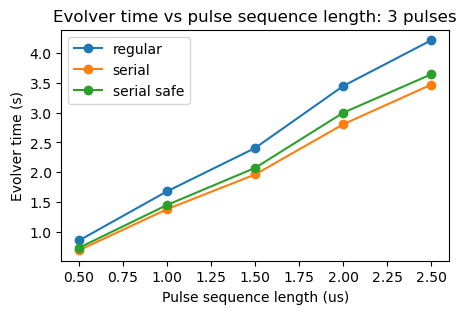

In [35]:
plt.figure(figsize = (5,3))
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[5:10], label='regular', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_avg_fin[5:10], label='serial', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[5:10], label='serial safe', marker = 'o')
plt.xlabel('Pulse sequence length (us)')
plt.ylabel('Evolver time (s)')
plt.title('Evolver time vs pulse sequence length: 3 pulses')
plt.legend()

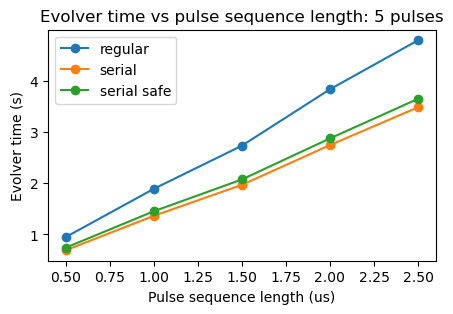

In [36]:
plt.figure(figsize = (5,3))
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[10:15], label='regular', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_avg_fin[10:15], label='serial', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[10:15], label='serial safe', marker = 'o')
plt.xlabel('Pulse sequence length (us)')
plt.ylabel('Evolver time (s)')
plt.title('Evolver time vs pulse sequence length: 5 pulses')
plt.legend()

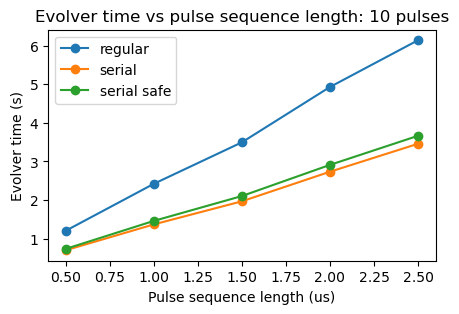

In [37]:
plt.figure(figsize = (5,3))
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[15:20], label='regular', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_avg_fin[15:20], label='serial', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[15:20], label='serial safe', marker = 'o')
plt.xlabel('Pulse sequence length (us)')
plt.ylabel('Evolver time (s)')
plt.title('Evolver time vs pulse sequence length: 10 pulses')
plt.legend()

### Put Regular and Serial_s in the same plot

Text(0.5, 1.0, 'Evolver time vs pulse sequence length')

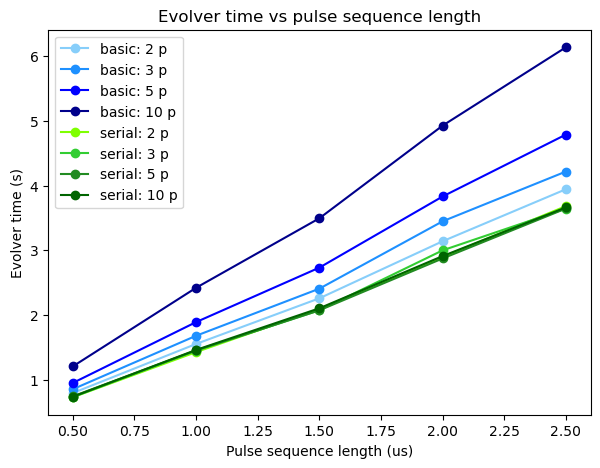

In [38]:
plt.figure(figsize = (7,5))
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[:5], label='basic: 2 p', marker = 'o', color = 'lightskyblue')
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[5:10], label='basic: 3 p', marker = 'o', color = 'dodgerblue')
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[10:15], label='basic: 5 p', marker = 'o', color = 'blue')
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[15:20], label='basic: 10 p', marker = 'o', color = 'darkblue')

plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[:5], label='serial: 2 p', marker = 'o', color = 'chartreuse')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[5:10], label='serial: 3 p', marker = 'o', color = 'limegreen')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[10:15], label='serial: 5 p', marker = 'o', color = 'forestgreen')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[15:20], label='serial: 10 p', marker = 'o', color = 'darkgreen')
plt.legend()
plt.xlabel('Pulse sequence length (us)')
plt.ylabel('Evolver time (s)')
plt.title('Evolver time vs pulse sequence length')

In [39]:
from scipy.optimize import curve_fit

def linear(x, m, b):
    return m*x+b 

basic_slopes = np.zeros(4)
serial_slopes = np.zeros(4)

for i in range(4):
    popt, pcov = curve_fit(linear, seq_duration*np.arange(1,6), reg_avg_fin[5*i:5*(i+1)])
    basic_slopes[i] = popt[0]
    popt, pcov = curve_fit(linear, seq_duration*np.arange(1,6), serial_safe_avg_fin[5*i:5*(i+1)])
    serial_slopes[i] = popt[0]

Text(0.5, 1.0, 'Change in evolver time per 1 us increase in pulse sequence duration')

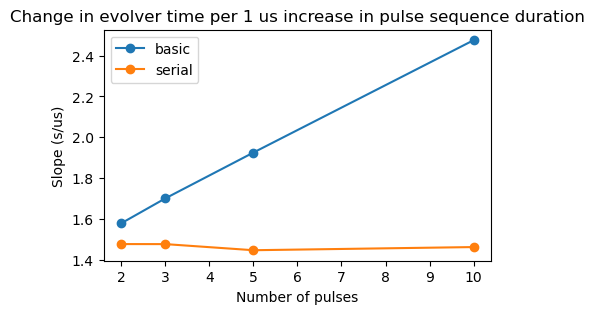

In [40]:
plt.figure(figsize = (5, 3))
plt.plot(num_pulses, basic_slopes, label = 'basic', marker = 'o')
plt.plot(num_pulses, serial_slopes, label = 'serial', marker = 'o')
plt.legend()
plt.xlabel('Number of pulses')
plt.ylabel('Slope (s/us)')
plt.title('Change in evolver time per 1 us increase in pulse sequence duration')

Text(0.5, 1.0, 'Change in evolver time')

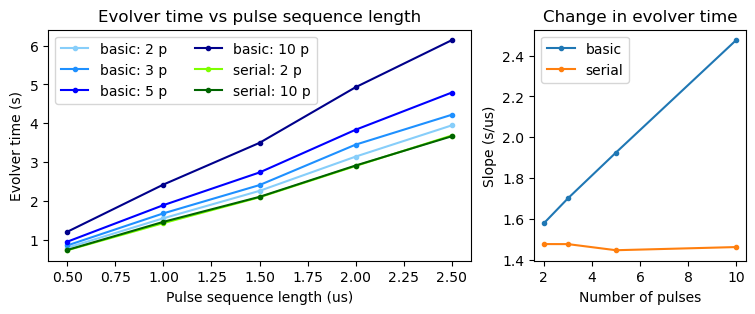

In [41]:
fig, axs = plt.subplots(1, 2, width_ratios = (2,1), figsize = (9,3))
axs[0].plot(seq_duration*np.arange(1,6), reg_avg_fin[:5], label='basic: 2 p', marker = '.', color = 'lightskyblue')
axs[0].plot(seq_duration*np.arange(1,6), reg_avg_fin[5:10], label='basic: 3 p', marker = '.', color = 'dodgerblue')
axs[0].plot(seq_duration*np.arange(1,6), reg_avg_fin[10:15], label='basic: 5 p', marker = '.', color = 'blue')
axs[0].plot(seq_duration*np.arange(1,6), reg_avg_fin[15:20], label='basic: 10 p', marker = '.', color = 'darkblue')
axs[0].plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[:5], label='serial: 2 p', marker = '.', color = 'chartreuse')
axs[0].plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[15:20], label='serial: 10 p', marker = '.', color = 'darkgreen')
axs[0].legend(loc = 'upper left', ncol = 2)
axs[0].set_xlabel('Pulse sequence length (us)')
axs[0].set_ylabel('Evolver time (s)')
axs[0].set_title('Evolver time vs pulse sequence length')

axs[1].plot(num_pulses, basic_slopes, label = 'basic', marker = '.')
axs[1].plot(num_pulses, serial_slopes, label = 'serial', marker = '.')
axs[1].legend()
axs[1].set_xlabel('Number of pulses')
axs[1].set_ylabel('Slope (s/us)')
axs[1].set_title('Change in evolver time')

In [62]:
# define options for mesolve
opts = Options(rhs_reuse = False, nsteps = 1000000, atol=1e-9, rtol=1e-9, tidy=False)

# max number of pulses
num_pulses = [2, 3, 5, 10]
seq_duration = 0.5

sequence_start = time.time()

reg_avg = []
serial_avg = []
serial_safe_avg = []

# loop through each # of pulses
for n in num_pulses:

    # loop through pulse sequence length
    for j in np.arange(1,6):

        # create a pulse sequence
        ps0 = Pulse_sequence(Hstat = Hstat)

        # tlist
        t_max = seq_duration*j
        
        arr_times = np.linspace(0, t_max, 100)
        if n == 3:
            if j == 1 or j == 2 or j == 4:
                arr_times = np.delete(arr_times, [33, 66])

        dt = t_max/n

        # place pulses in sequence one right after the other
        for i in np.arange(n):
            starttime = i*dt

            if i == n-1:
                duration = t_max-starttime
            else: 
                duration = dt

            ps0.add_pulse(Pulse(emptypulse, start_time = starttime, duration = duration, coeff_params = {}))
            #ps0.add_pulse(Pulse(ACDpulsetype, start_time = starttime, duration = duration, coeff_params = {'B_amp': B_amp, 'freq': frq_trans}))

        # initialize evolver objects (no difference at this point)
        ev = Evolver(state_init, arr_times, ps0, opts = opts)

        # save runtime values
        reg_times = []
        serial_times = []
        serial_safe_times = []
        
        for k in np.arange(6): 

            # run the regular evolution method, where each pulse's time dependent coefficient is calculated at each time step
            start1 = time.time()
            reg_res = ev.evolve(method = 'regular')
            end1 = time.time()
            reg_diff = end1-start1

            # run the serial evolution method, where each pulse represents its of segment integrated separately
            start2 = time.time()
            serial_res = ev.evolve(method = 'serial')
            end2 = time.time()
            serial_diff = end2-start2
            
            # makeshift progress bar
            #print(k)

            # run the safe serial method, which handles tolerances more faithfully to regular
            start3 = time.time()
            serial_safe_res = ev.evolve(method = 'serial_safe')
            end3 = time.time()
            serial_safe_diff = end3-start3

            reg_times.append(reg_diff)
            serial_times.append(serial_diff)
            serial_safe_times.append(serial_safe_diff)
            
        reg_avg.append(reg_times)
        serial_avg.append(serial_times)
        serial_safe_avg.append(serial_safe_times)
    
print("Total time: ", (time.time()-sequence_start)/60)

Total time:  10.662071935335796


In [63]:
reg_avg_fin = []
serial_avg_fin = []
serial_safe_avg_fin = []

for i in np.arange(len(reg_avg)):
    reg_avg_fin.append(sum(reg_avg[i])/6)
    serial_avg_fin.append(sum(serial_avg[i])/6)
    serial_safe_avg_fin.append(sum(serial_safe_avg[i])/6)

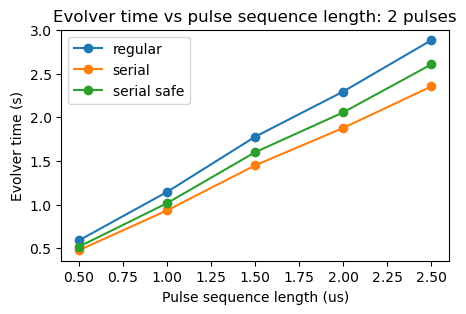

In [64]:
plt.figure(figsize = (5,3))
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[:5], label='regular', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_avg_fin[:5], label='serial', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[:5], label='serial safe', marker = 'o')
plt.xlabel('Pulse sequence length (us)')
plt.ylabel('Evolver time (s)')
plt.title('Evolver time vs pulse sequence length: 2 pulses')
plt.legend()

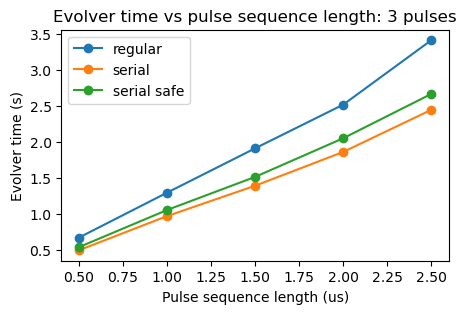

In [65]:
plt.figure(figsize = (5,3))
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[5:10], label='regular', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_avg_fin[5:10], label='serial', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[5:10], label='serial safe', marker = 'o')
plt.xlabel('Pulse sequence length (us)')
plt.ylabel('Evolver time (s)')
plt.title('Evolver time vs pulse sequence length: 3 pulses')
plt.legend()

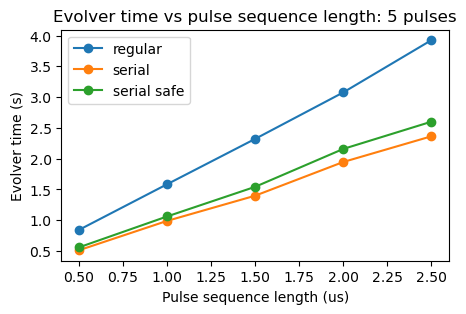

In [66]:
plt.figure(figsize = (5,3))
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[10:15], label='regular', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_avg_fin[10:15], label='serial', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[10:15], label='serial safe', marker = 'o')
plt.xlabel('Pulse sequence length (us)')
plt.ylabel('Evolver time (s)')
plt.title('Evolver time vs pulse sequence length: 5 pulses')
plt.legend()

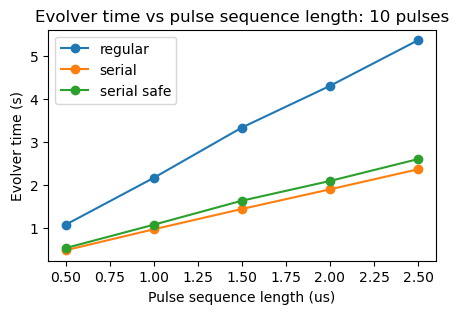

In [67]:
plt.figure(figsize = (5,3))
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[15:20], label='regular', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_avg_fin[15:20], label='serial', marker = 'o')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[15:20], label='serial safe', marker = 'o')
plt.xlabel('Pulse sequence length (us)')
plt.ylabel('Evolver time (s)')
plt.title('Evolver time vs pulse sequence length: 10 pulses')
plt.legend()

Text(0.5, 1.0, 'Evolver time vs pulse sequence length')

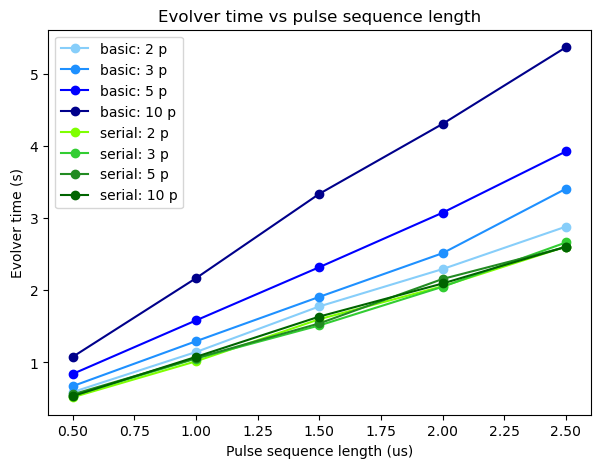

In [68]:
plt.figure(figsize = (7,5))
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[:5], label='basic: 2 p', marker = 'o', color = 'lightskyblue')
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[5:10], label='basic: 3 p', marker = 'o', color = 'dodgerblue')
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[10:15], label='basic: 5 p', marker = 'o', color = 'blue')
plt.plot(seq_duration*np.arange(1,6), reg_avg_fin[15:20], label='basic: 10 p', marker = 'o', color = 'darkblue')

plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[:5], label='serial: 2 p', marker = 'o', color = 'chartreuse')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[5:10], label='serial: 3 p', marker = 'o', color = 'limegreen')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[10:15], label='serial: 5 p', marker = 'o', color = 'forestgreen')
plt.plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[15:20], label='serial: 10 p', marker = 'o', color = 'darkgreen')
plt.legend()
plt.xlabel('Pulse sequence length (us)')
plt.ylabel('Evolver time (s)')
plt.title('Evolver time vs pulse sequence length')

In [69]:
from scipy.optimize import curve_fit

def linear(x, m, b):
    return m*x+b 

basic_slopes = np.zeros(4)
serial_slopes = np.zeros(4)

for i in range(4):
    popt, pcov = curve_fit(linear, seq_duration*np.arange(1,6), reg_avg_fin[5*i:5*(i+1)])
    basic_slopes[i] = popt[0]
    popt, pcov = curve_fit(linear, seq_duration*np.arange(1,6), serial_safe_avg_fin[5*i:5*(i+1)])
    serial_slopes[i] = popt[0]

Text(0.5, 1.0, 'Change in evolver time per 1 us increase in pulse sequence duration')

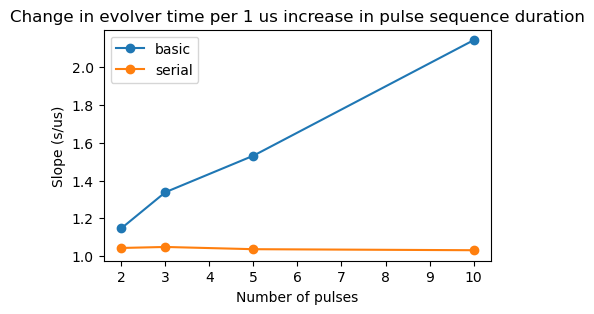

In [70]:
plt.figure(figsize = (5, 3))
plt.plot(num_pulses, basic_slopes, label = 'basic', marker = 'o')
plt.plot(num_pulses, serial_slopes, label = 'serial', marker = 'o')
plt.legend()
plt.xlabel('Number of pulses')
plt.ylabel('Slope (s/us)')
plt.title('Change in evolver time per 1 us increase in pulse sequence duration')

Text(0.5, 1.0, 'Change in evolver time')

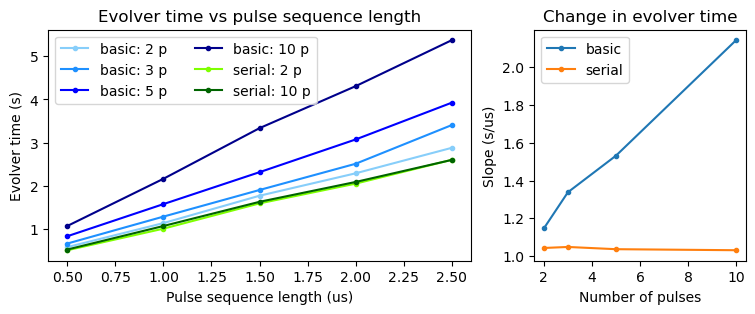

In [71]:
fig, axs = plt.subplots(1, 2, width_ratios = (2,1), figsize = (9,3))
axs[0].plot(seq_duration*np.arange(1,6), reg_avg_fin[:5], label='basic: 2 p', marker = '.', color = 'lightskyblue')
axs[0].plot(seq_duration*np.arange(1,6), reg_avg_fin[5:10], label='basic: 3 p', marker = '.', color = 'dodgerblue')
axs[0].plot(seq_duration*np.arange(1,6), reg_avg_fin[10:15], label='basic: 5 p', marker = '.', color = 'blue')
axs[0].plot(seq_duration*np.arange(1,6), reg_avg_fin[15:20], label='basic: 10 p', marker = '.', color = 'darkblue')
axs[0].plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[:5], label='serial: 2 p', marker = '.', color = 'chartreuse')
axs[0].plot(seq_duration*np.arange(1,6), serial_safe_avg_fin[15:20], label='serial: 10 p', marker = '.', color = 'darkgreen')
axs[0].legend(loc = 'upper left', ncol = 2)
axs[0].set_xlabel('Pulse sequence length (us)')
axs[0].set_ylabel('Evolver time (s)')
axs[0].set_title('Evolver time vs pulse sequence length')

axs[1].plot(num_pulses, basic_slopes, label = 'basic', marker = '.')
axs[1].plot(num_pulses, serial_slopes, label = 'serial', marker = '.')
axs[1].legend()
axs[1].set_xlabel('Number of pulses')
axs[1].set_ylabel('Slope (s/us)')
axs[1].set_title('Change in evolver time')